# Description
```
Name      : project_covid_1
Problem   : Classification
Type      : Deep learning
Algorithm : Convolutional neural network : CNN
Formula   : Weightes-Sum
Action    : Relu | softmax
Loss      : Cross-Entropy-Binary
Train     : Supervised | Transfer
Input     : Feature and label
Output    : Binary
Dataset   : Unstructured : covid19
```

# General

### Import

In [397]:
import glob, os
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from keras import optimizers
from keras.utils import to_categorical
from keras import models, layers
from keras.models import load_model
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator

### Variable

In [398]:
root_dir = '/Volumes/data/documents/ai_document'
dataset_dir = f"{root_dir}/dataset/covid19"

# Dataset

### Rename

In [ ]:
directory_1 = 'covid'
directory_2 = 'normal' 
number_1 = '001'
number_2 = '001'
extension_new = 'jpeg'

for address in glob.glob(f"{dataset_dir}/**/*.*", recursive=True):
    path = os.path.dirname(address)
    directory = path.split('/')[-1].split('.')[0]
    name = os.path.splitext(os.path.basename(address))[0]
    extension = os.path.splitext(os.path.basename(address))[1] 

    src = os.path.join(path, f"{name}{extension}")
    if directory == directory_1 : 
        dst = os.path.join(path, f"{number_1}_{directory}.{extension_new}")
        number_1 = str(int(number_1) + 1).zfill(3)    
    if directory == directory_2 : 
        dst = os.path.join(path, f"{number_2}_{directory}.{extension_new}")
        number_2 = str(int(number_2) + 1).zfill(3)
    
    if not os.path.exists(dst):             
        os.rename(src, dst)

### Data

In [400]:
dataset = []
for address in glob.glob(f"{dataset_dir}/**/*.*", recursive=True):
    img = cv.imread(address)
    dataset.append(img)
print("len: {}".format(len(dataset)))

len: 50


### Label

#### Split

In [401]:
labels = []
for address in glob.glob(f"{dataset_dir}/**/*.*", recursive=True):
    label = address.split('/')[-2].split('.')[0]
    labels.append(label)

print("len: {}".format(len(labels)))

len: 50


#### Convert label to encoding

In [402]:
le = LabelEncoder()
label_encode = le.fit_transform(labels)
label_encode = to_categorical(label_encode, 2)

print("Shape: {}".format(label_encode.shape))

Shape: (50, 2)


# Preprocessing

In [403]:
data = []
for img in dataset:
    #---Resize
    img = cv.resize(img, (224, 224))
    #---Normalization
    img = img/255.0
    #---Add
    data.append(img)
#---Convert
data = np.array(data)

print("Shape: {}".format(data.shape))

Shape: (50, 224, 224, 3)


# Separate tarin and test

In [404]:
x_train, x_test, y_train, y_test = train_test_split(
    data, 
    label_encode, 
    test_size=0.15, 
    random_state=42
)
print(x_train.shape)
print(x_test.shape)
print(len(y_train))
print(len(y_test))

(42, 224, 224, 3)
(8, 224, 224, 3)
42
8


# Data Augmentation

In [405]:
aug = ImageDataGenerator(
    rotation_range=10,
    fill_mode='nearest'
)

# Model

### Base model

In [406]:
# baseModel = VGG16(
#    weights = "imagenet",
#    include_top= False,
#    input_tensor = layers.Input(shape = (224, 224, 3))
#    )

baseModel = VGG16(
    include_top=False,
    input_tensor = layers.Input(shape = (224, 224, 3)),
    weights=f"{root_dir}/model/vgg16_weights_tf_dim_ordering_tf_kernels_notop.h5"
)

for layer in baseModel.layers:
    layer.trainable = False

### Optimizers

In [407]:
opt_sgd = optimizers.SGD(
    learning_rate=0.001,
    decay=0.001/255
)

opt_adam = optimizers.Adam(
    learning_rate=0.001, 
    decay=0.001/255
)

/Volumes/data/documents/ai_document/.myenv3/lib/python3.9/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


### Model

In [408]:
mdl = models.Sequential()
mdl.add(baseModel)
mdl.add(layers.MaxPool2D(pool_size=(4, 4))) 
mdl.add(layers.Flatten())
mdl.add(layers.Dense(64, activation="relu"))
mdl.add(layers.Dense(2, activation="softmax"))

mdl.compile(
    #optimizer=opt_sgd, 
    optimizer=opt_adam, 
    loss="binary_crossentropy", 
    metrics=["accuracy"]
)

mdl.summary()

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_15 (Flatten)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,747,650 (56.26 MB)

 Trainable params: 32,962 (128.76 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

# Train

In [409]:
EPOCHS = 25
BATCH_SIZE = 8
output_label = ['fire', 'nofire']
h = mdl.fit(
    aug.flow(x_train, y_train, batch_size=8),
    steps_per_epoch=len(x_train)//8,
    validation_data=(x_test, y_test),
    epochs=EPOCHS
)

Epoch 1/25


/Volumes/data/documents/ai_document/.myenv3/lib/python3.9/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 425ms/step - accuracy: 0.5063 - loss: 0.7855 - val_accuracy: 0.7500 - val_loss: 0.6578
Epoch 2/25
1/5 ━━━━━━━━━━━━━━━━━━━━ 1s 370ms/step - accuracy: 0.7500 - loss: 0.6569

/Volumes/data/documents/ai_document/.myenv3/lib/python3.9/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - accuracy: 0.7500 - loss: 0.6569 - val_accuracy: 1.0000 - val_loss: 0.6195
Epoch 3/25
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 430ms/step - accuracy: 0.6740 - loss: 0.6454 - val_accuracy: 1.0000 - val_loss: 0.5848
Epoch 4/25
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - accuracy: 1.0000 - loss: 0.5774 - val_accuracy: 0.8750 - val_loss: 0.6043
Epoch 5/25
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 477ms/step - accuracy: 0.8347 - loss: 0.5742 - val_accuracy: 0.3750 - val_loss: 0.6960
Epoch 6/25
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.5000 - loss: 0.6159 - val_accuracy: 0.3750 - val_loss: 0.6885
Epoch 7/25
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 436ms/step - accuracy: 0.8336 - loss: 0.4896 - val_accuracy: 0.5000 - val_loss: 0.5924
Epoch 8/25
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - accuracy: 1.0000 - loss: 0.5061 - val_accuracy: 0.7500 - val_loss: 0.5698
Epoch 9/25
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 400ms/step - accuracy: 0.9098 - loss: 0.4869 - val_accuracy: 0.8750 - val_loss: 0.5014
Epoch 1

# Evaluation

### Loss and Accuracy

In [410]:
loss, accuracy = mdl.evaluate(x_test, y_test)
print("Loss: {:.2f} | Accuracy: {:.2f}".format(loss, accuracy))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accuracy: 0.7500 - loss: 0.4961
Loss: 0.50 | Accuracy: 0.75


### History

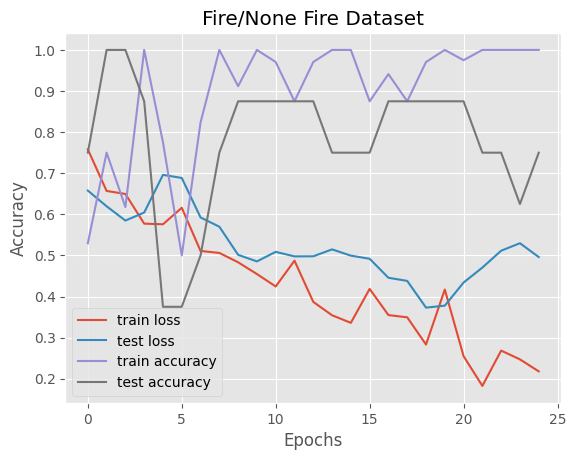

In [414]:
plt.plot(h.history['loss'], label='train loss')
plt.plot(h.history['val_loss'], label='test loss')
plt.plot(h.history['accuracy'], label='train accuracy')
plt.plot(h.history['val_accuracy'], label='test accuracy')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Fire/None Fire Dataset')
plt.style.use('ggplot')
plt.show()

# Save model

In [412]:
mdl.save(f"{root_dir}/model/VGG16_1.h5")

# Test

In [413]:
mdl = load_model(f"{root_dir}/model/VGG16_1.h5")
for address in glob.glob(f"{dataset_dir}/predict/*.*"):
    img = cv.imread(address)
    img = cv.resize(img, (32, 32))
    img = img/255.0
    img = np.array([img])
    pred = mdl.predict(img)[0]
    pred_max = np.argmax(pred)
    out = output_label[pred_max]
    name = address.split('/')[-1].split('.')[0]
    print("{}.jpg : {}".format(name, out))

    img = cv.imread(address)
    img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.show()
